In [1]:
import ipaddress
import pandas as pd
import matplotlib.pyplot as plt

# Keep consistent with other analysis notebooks
TIME_OFFSET = 10800

In [2]:
def plot_mean_frame_len_per_src_ip(
    input_csv,
    src_ip,
    center_timestamp,
    interval_seconds,
    time_offset_seconds=TIME_OFFSET,
):
    """
    1) Plot mean(frame.len) per src IP in 1-second bins for
    [center_timestamp - interval_seconds, center_timestamp + interval_seconds].
    """
    ipaddress.ip_address(src_ip)
    df = pd.read_csv(input_csv)

    required_cols = {"ip.src", "frame.time_epoch", "frame.len"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required column(s): {sorted(missing)}")

    epoch = pd.to_numeric(df["frame.time_epoch"], errors="coerce")
    df = df.loc[epoch.notna()].copy()
    df["aligned_ts"] = pd.to_datetime(epoch[epoch.notna()] + float(time_offset_seconds), unit="s", errors="coerce")
    df["frame.len"] = pd.to_numeric(df["frame.len"], errors="coerce")

    center_ts = pd.to_datetime(center_timestamp, errors="raise")
    start_ts = center_ts - pd.Timedelta(seconds=int(interval_seconds))
    end_ts = center_ts + pd.Timedelta(seconds=int(interval_seconds))

    src_df = df[df["ip.src"].astype(str) == src_ip].copy()
    window_df = src_df[(src_df["aligned_ts"] >= start_ts) & (src_df["aligned_ts"] <= end_ts)].copy()
    window_df["second_bin"] = window_df["aligned_ts"].dt.floor("s")

    center_second = center_ts.floor("s")
    bins = pd.date_range(
        start=center_second - pd.Timedelta(seconds=int(interval_seconds)),
        end=center_second + pd.Timedelta(seconds=int(interval_seconds)),
        freq="s",
    )
    rel_x = (bins - center_second).total_seconds().astype(int)

    series = window_df.groupby("second_bin")["frame.len"].mean().reindex(bins)

    plt.figure(figsize=(11, 4))
    plt.plot(rel_x, series.values, marker="o")
    plt.axvline(0, color="black", linestyle="--", linewidth=1, label="Target timestamp")
    plt.xlabel("Seconds offset from target timestamp")
    plt.ylabel("mean(frame.len)")
    plt.title(f"Mean frame.len for src={src_ip} around {center_ts} (+/-{interval_seconds}s)")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return series


def plot_max_frame_len_per_src_ip(
    input_csv,
    src_ip,
    center_timestamp,
    interval_seconds,
    time_offset_seconds=TIME_OFFSET,
):
    """
    2) Plot max(frame.len) per src IP in 1-second bins.
    """
    ipaddress.ip_address(src_ip)
    df = pd.read_csv(input_csv)

    required_cols = {"ip.src", "frame.time_epoch", "frame.len"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required column(s): {sorted(missing)}")

    epoch = pd.to_numeric(df["frame.time_epoch"], errors="coerce")
    df = df.loc[epoch.notna()].copy()
    df["aligned_ts"] = pd.to_datetime(epoch[epoch.notna()] + float(time_offset_seconds), unit="s", errors="coerce")
    df["frame.len"] = pd.to_numeric(df["frame.len"], errors="coerce")

    center_ts = pd.to_datetime(center_timestamp, errors="raise")
    start_ts = center_ts - pd.Timedelta(seconds=int(interval_seconds))
    end_ts = center_ts + pd.Timedelta(seconds=int(interval_seconds))

    src_df = df[df["ip.src"].astype(str) == src_ip].copy()
    window_df = src_df[(src_df["aligned_ts"] >= start_ts) & (src_df["aligned_ts"] <= end_ts)].copy()
    window_df["second_bin"] = window_df["aligned_ts"].dt.floor("s")

    center_second = center_ts.floor("s")
    bins = pd.date_range(
        start=center_second - pd.Timedelta(seconds=int(interval_seconds)),
        end=center_second + pd.Timedelta(seconds=int(interval_seconds)),
        freq="s",
    )
    rel_x = (bins - center_second).total_seconds().astype(int)

    series = window_df.groupby("second_bin")["frame.len"].max().reindex(bins)

    plt.figure(figsize=(11, 4))
    plt.plot(rel_x, series.values, marker="o")
    plt.axvline(0, color="black", linestyle="--", linewidth=1, label="Target timestamp")
    plt.xlabel("Seconds offset from target timestamp")
    plt.ylabel("max(frame.len)")
    plt.title(f"Max frame.len for src={src_ip} around {center_ts} (+/-{interval_seconds}s)")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return series


def plot_mean_mbtcp_len_per_src_ip(
    input_csv,
    src_ip,
    center_timestamp,
    interval_seconds,
    mbtcp_len_col="mbtcp.len",
    time_offset_seconds=TIME_OFFSET,
):
    """
    3) Plot mean(mbtcp.len) per src IP in 1-second bins.
    """
    ipaddress.ip_address(src_ip)
    df = pd.read_csv(input_csv)

    required_cols = {"ip.src", "frame.time_epoch", mbtcp_len_col}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required column(s): {sorted(missing)}")

    epoch = pd.to_numeric(df["frame.time_epoch"], errors="coerce")
    df = df.loc[epoch.notna()].copy()
    df["aligned_ts"] = pd.to_datetime(epoch[epoch.notna()] + float(time_offset_seconds), unit="s", errors="coerce")
    df[mbtcp_len_col] = pd.to_numeric(df[mbtcp_len_col], errors="coerce")

    center_ts = pd.to_datetime(center_timestamp, errors="raise")
    start_ts = center_ts - pd.Timedelta(seconds=int(interval_seconds))
    end_ts = center_ts + pd.Timedelta(seconds=int(interval_seconds))

    src_df = df[df["ip.src"].astype(str) == src_ip].copy()
    window_df = src_df[(src_df["aligned_ts"] >= start_ts) & (src_df["aligned_ts"] <= end_ts)].copy()
    window_df["second_bin"] = window_df["aligned_ts"].dt.floor("s")

    center_second = center_ts.floor("s")
    bins = pd.date_range(
        start=center_second - pd.Timedelta(seconds=int(interval_seconds)),
        end=center_second + pd.Timedelta(seconds=int(interval_seconds)),
        freq="s",
    )
    rel_x = (bins - center_second).total_seconds().astype(int)

    series = window_df.groupby("second_bin")[mbtcp_len_col].mean().reindex(bins)

    plt.figure(figsize=(11, 4))
    plt.plot(rel_x, series.values, marker="o")
    plt.axvline(0, color="black", linestyle="--", linewidth=1, label="Target timestamp")
    plt.xlabel("Seconds offset from target timestamp")
    plt.ylabel(f"mean({mbtcp_len_col})")
    plt.title(f"Mean mbtcp length for src={src_ip} around {center_ts} (+/-{interval_seconds}s)")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return series


def plot_mean_modbus_byte_cnt_per_src_ip(
    input_csv,
    src_ip,
    center_timestamp,
    interval_seconds,
    byte_cnt_col="modbus.byte_cnt",
    time_offset_seconds=TIME_OFFSET,
):
    """
    4) Plot mean(modbus.byte_cnt) per src IP in 1-second bins.
    """
    ipaddress.ip_address(src_ip)
    df = pd.read_csv(input_csv)

    required_cols = {"ip.src", "frame.time_epoch", byte_cnt_col}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required column(s): {sorted(missing)}")

    epoch = pd.to_numeric(df["frame.time_epoch"], errors="coerce")
    df = df.loc[epoch.notna()].copy()
    df["aligned_ts"] = pd.to_datetime(epoch[epoch.notna()] + float(time_offset_seconds), unit="s", errors="coerce")
    df[byte_cnt_col] = pd.to_numeric(df[byte_cnt_col], errors="coerce")

    center_ts = pd.to_datetime(center_timestamp, errors="raise")
    start_ts = center_ts - pd.Timedelta(seconds=int(interval_seconds))
    end_ts = center_ts + pd.Timedelta(seconds=int(interval_seconds))

    src_df = df[df["ip.src"].astype(str) == src_ip].copy()
    window_df = src_df[(src_df["aligned_ts"] >= start_ts) & (src_df["aligned_ts"] <= end_ts)].copy()
    window_df["second_bin"] = window_df["aligned_ts"].dt.floor("s")

    center_second = center_ts.floor("s")
    bins = pd.date_range(
        start=center_second - pd.Timedelta(seconds=int(interval_seconds)),
        end=center_second + pd.Timedelta(seconds=int(interval_seconds)),
        freq="s",
    )
    rel_x = (bins - center_second).total_seconds().astype(int)

    series = window_df.groupby("second_bin")[byte_cnt_col].mean().reindex(bins)

    plt.figure(figsize=(11, 4))
    plt.plot(rel_x, series.values, marker="o")
    plt.axvline(0, color="black", linestyle="--", linewidth=1, label="Target timestamp")
    plt.xlabel("Seconds offset from target timestamp")
    plt.ylabel(f"mean({byte_cnt_col})")
    plt.title(f"Mean modbus.byte_cnt for src={src_ip} around {center_ts} (+/-{interval_seconds}s)")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return series


# Example usage:
# input_csv = "../train/cscada_attack_ssw.csv"
# src_ip = "185.175.0.5"
# center_timestamp = "2023-03-19 03:01:57.813"
# x = 20
#
# plot_mean_frame_len_per_src_ip(input_csv, src_ip, center_timestamp, x)
# plot_max_frame_len_per_src_ip(input_csv, src_ip, center_timestamp, x)
# plot_mean_mbtcp_len_per_src_ip(input_csv, src_ip, center_timestamp, x)
# plot_mean_modbus_byte_cnt_per_src_ip(input_csv, src_ip, center_timestamp, x)

/tmp/ipykernel_465956/387086199.py:13: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16, 11: modbus.data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


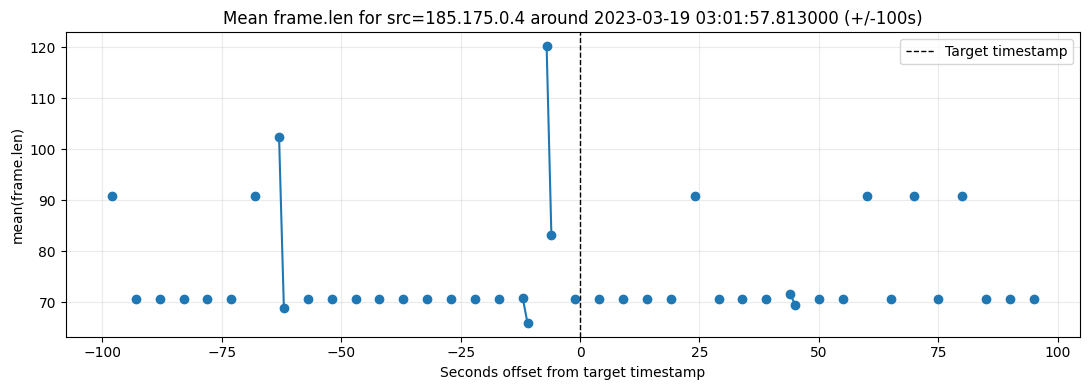

/tmp/ipykernel_465956/387086199.py:13: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16, 11: modbus.data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


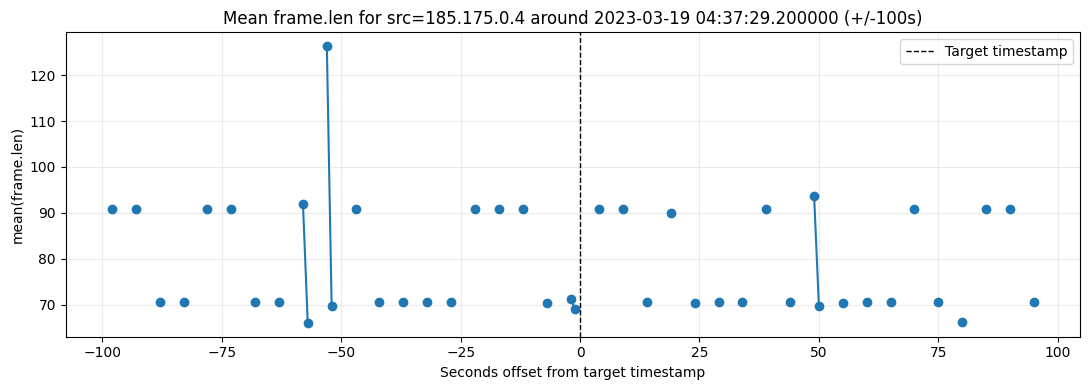

2023-03-19 04:35:49       NaN
2023-03-19 04:35:50       NaN
2023-03-19 04:35:51    90.875
2023-03-19 04:35:52       NaN
2023-03-19 04:35:53       NaN
                        ...  
2023-03-19 04:39:05       NaN
2023-03-19 04:39:06       NaN
2023-03-19 04:39:07       NaN
2023-03-19 04:39:08       NaN
2023-03-19 04:39:09       NaN
Freq: s, Name: frame.len, Length: 201, dtype: float64

In [6]:
plot_mean_frame_len_per_src_ip("../train/cscada_attack_ssw_analysis.csv", "185.175.0.4", "2023-03-19 03:01:57.813", 100)
plot_mean_frame_len_per_src_ip("../train/cscada_attack_ssw_analysis.csv", "185.175.0.4", "2023-03-19 04:37:29.2", 100)

/tmp/ipykernel_465956/387086199.py:68: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16, 11: modbus.data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


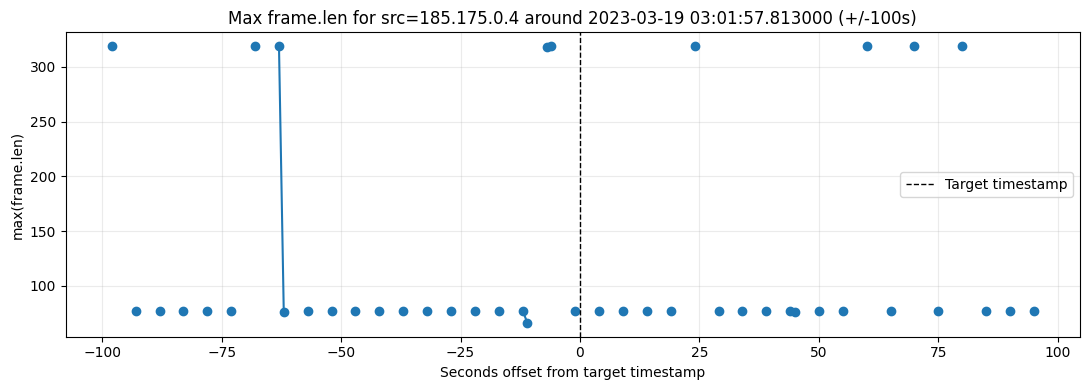

/tmp/ipykernel_465956/387086199.py:68: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16, 11: modbus.data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


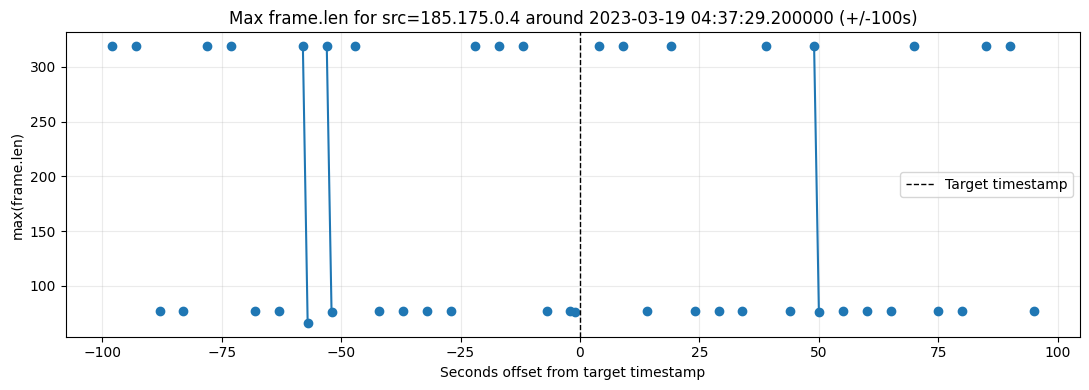

2023-03-19 04:35:49      NaN
2023-03-19 04:35:50      NaN
2023-03-19 04:35:51    319.0
2023-03-19 04:35:52      NaN
2023-03-19 04:35:53      NaN
                       ...  
2023-03-19 04:39:05      NaN
2023-03-19 04:39:06      NaN
2023-03-19 04:39:07      NaN
2023-03-19 04:39:08      NaN
2023-03-19 04:39:09      NaN
Freq: s, Name: frame.len, Length: 201, dtype: float64

In [7]:
plot_max_frame_len_per_src_ip("../train/cscada_attack_ssw_analysis.csv", "185.175.0.4", "2023-03-19 03:01:57.813", 100)
plot_max_frame_len_per_src_ip("../train/cscada_attack_ssw_analysis.csv", "185.175.0.4", "2023-03-19 04:37:29.2", 100)